# Laboratorium 9:

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")
%matplotlib inline


In [37]:
df = pd.read_excel('data.xlsx', engine='openpyxl')

print(f'Wczytano {len(df)} wierszy i {len(df.columns)} kolumn')
df.drop(df.columns[0], axis=1, inplace=True)
display(df.head())

X = df['X'].values.reshape(-1, 1)
y = df['Y'].values

print(f"X shape: {X.shape}, y shape: {y.shape}")

Wczytano 100 wierszy i 3 kolumn


,X,Y
0,-0.015981,0.001984
1,-0.012942,-0.000511
2,-0.018796,0.008553
3,-0.019340,-0.019842
4,0.015664,-0.002325


X shape: (100, 1), y shape: (100,)


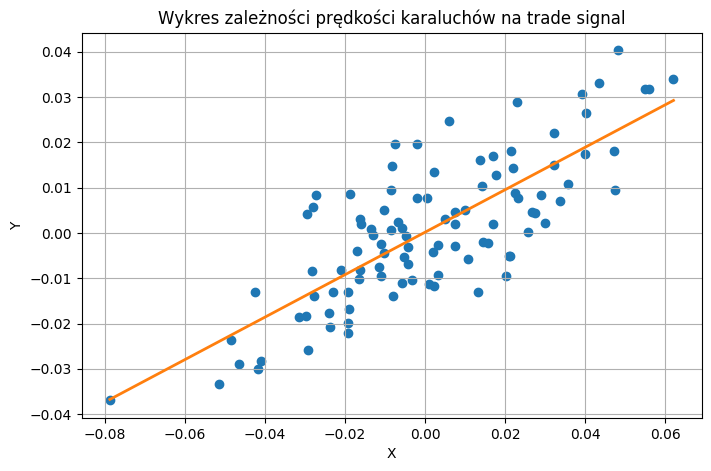

In [38]:
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
mse = mean_squared_error(y, y_pred)
sort_idx = X.ravel().argsort()
y_pred_sorted = y_pred[sort_idx]

plt.figure(figsize=(8,5))
plt.scatter(X.ravel(), y, c='C0')
plt.plot(X.ravel()[sort_idx], y_pred_sorted, c='C1', linewidth=2, )
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Wykres zależności prędkości karaluchów na trade signal')
plt.grid(True)
plt.show()


In [39]:
def stock_loss(factual, predicted, coef = 100.):
    if factual * predicted < 0:
        return coef * predicted**2 + abs(factual - predicted)
    else:
        return abs(factual - predicted)

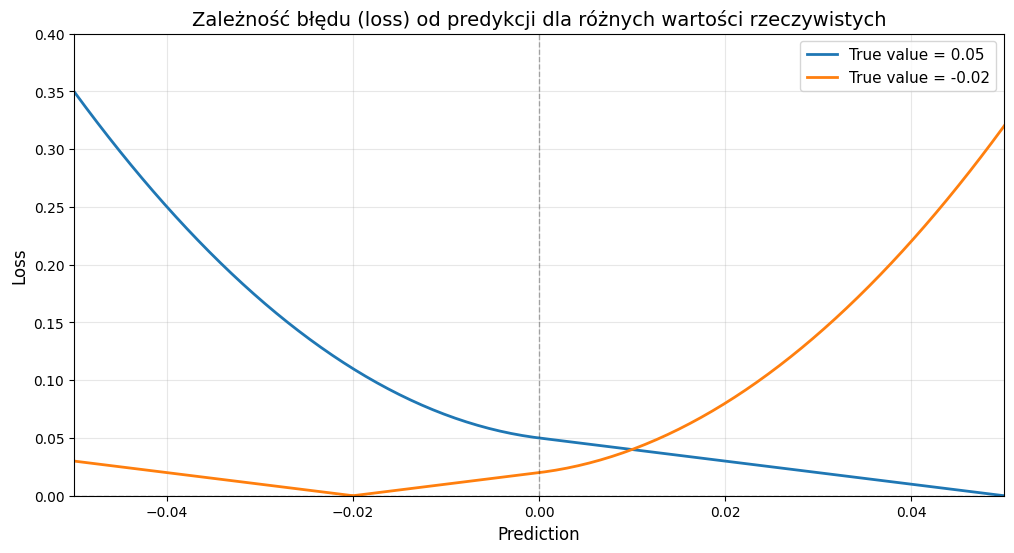

In [40]:
predictions = np.linspace(-0.1, 0.1, 500)

true_values = [0.05, -0.02]
colors = ['C0', 'C1']

plt.figure(figsize=(12, 6))

for true_val, color in zip(true_values, colors):
    losses_for_true_val = [stock_loss(true_val, pred) for pred in predictions]
    plt.plot(predictions, losses_for_true_val, label=f'True value = {true_val}', 
             linewidth=2, color=color)

plt.xlabel('Prediction', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Zależność błędu (loss) od predykcji dla różnych wartości rzeczywistych', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
plt.xlim(-0.05, 0.05)
plt.ylim(0, 0.4)
plt.show()


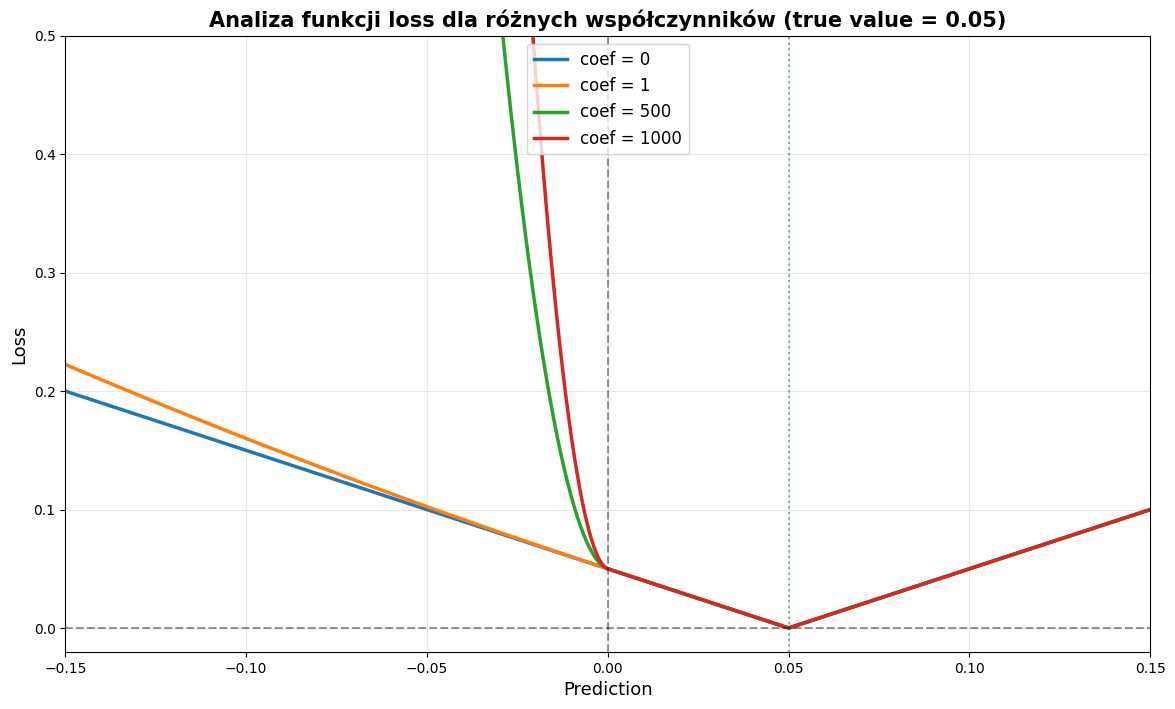

In [ ]:
predictions = np.linspace(-0.2, 0.2, 500)
coef_values = [0, 1, 500, 1000]
true_value = 0.05

plt.figure(figsize=(14, 8))

for coef in coef_values:
    losses = []
    for pred in predictions:
        if true_value * pred < 0:
            loss = coef * pred**2 + abs(true_value - pred)
        else:
            loss = abs(true_value - pred)
        losses.append(loss)
    
    plt.plot(predictions, losses, label=f'coef = {coef}', linewidth=2.5)

plt.xlabel('Prediction', fontsize=13)
plt.ylabel('Loss', fontsize=13)
plt.title(f'Analiza funkcji loss dla różnych współczynników (true value = {true_value})', 
          fontsize=15, fontweight='bold')
plt.legend(fontsize=12, loc='upper center')
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.4, linewidth=1.5)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.4, linewidth=1.5)
plt.axvline(x=true_value, color='green', linestyle=':', alpha=0.5, linewidth=1.5, label=f'True value = {true_value}')
plt.xlim(-0.15, 0.15)
plt.ylim(-0.02, 0.5)
plt.show()

Współczynnik coeff wpływa jedynie na wartości przeciwne znakiem (czyli konkretną pomyłkę ruchu podjętego na rynku). Uwypukla dodatkowo wagę tego błędu, im wieksza pomyłka tym większa strata.

Gdy współczynnik jest równy 0 (disabled), błąd nadal określany jest liniowo, bagatelizując fakt pomyłki ruchu podjętego na rynku.

In [ ]:
import pymc as pm
from scipy.optimize import fmin

def stock_loss_vect(factual_vect, predicted, coef=100):
    loss_vect = np.zeros_like(factual_vect)
    ix_vect = factual_vect * predicted < 0
    loss_vect[ix_vect] = coef * predicted ** 2 + np.abs(factual_vect[ix_vect] - predicted)
    loss_vect[~ix_vect] = np.abs(factual_vect[~ix_vect] - predicted)
    return loss_vect.mean()

print("Budowa modelu bayesowskiego...")
with pm.Model() as model:
    std = pm.Uniform("std", 0, 100)
    beta = pm.Normal("beta", mu=0, sigma=100)
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    mean = pm.Deterministic("mean", alpha + beta * X.ravel())
    obs = pm.Normal("obs", mu=mean, sigma=std, observed=y)
    
    print("Rozpoczęcie samplingu...")
    idata = pm.sample(2000, tune=1000, return_inferencedata=True, random_seed=42)

print("\nSampling zakończony!")
print(pm.summary(idata, var_names=["alpha", "beta", "std"]))

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Budowa modelu bayesowskiego...
Rozpoczęcie samplingu...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [std, beta, alpha]
NUTS: [std, beta, alpha]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 305 seconds.



Sampling zakończony!
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  0.000  0.001  -0.002    0.002        0.0      0.0   10812.0    6147.0   
beta   0.469  0.038   0.399    0.540        0.0      0.0   12014.0    6257.0   
std    0.010  0.001   0.009    0.012        0.0      0.0   11415.0    6010.0   

       r_hat  
alpha    1.0  
beta     1.0  
std      1.0  


In [ ]:
std_samples = idata.posterior["std"].values.flatten()
alpha_samples = idata.posterior["alpha"].values.flatten()
beta_samples = idata.posterior["beta"].values.flatten()
N = std_samples.shape[0]

print(f"Liczba próbek: {N}")
print(f"Alpha - średnia: {alpha_samples.mean():.4f}, std: {alpha_samples.std():.4f}")
print(f"Beta - średnia: {beta_samples.mean():.4f}, std: {beta_samples.std():.4f}")
print(f"Std - średnia: {std_samples.mean():.4f}, std: {std_samples.std():.4f}")

Liczba próbek: 8000
Alpha - średnia: 0.0002, std: 0.0010
Beta - średnia: 0.4687, std: 0.0376
Std - średnia: 0.0101, std: 0.0007


In [ ]:
trade_signals = np.linspace(X.min(), X.max(), 50)
opt_predictions = np.zeros(50)

print("Optymalizacja predykcji dla trade signals...")
for i, signal in enumerate(trade_signals):
    # Generowanie możliwych wyników dla danego trade signal
    noise = std_samples * np.random.randn(N)
    possible_outcomes = alpha_samples + beta_samples * signal + noise
    
    # Funkcja do minimalizacji
    def tomin(pred):
        return stock_loss_vect(possible_outcomes, pred)
    
    # Optymalizacja
    opt_predictions[i] = fmin(tomin, 0, disp=False)
    
    if (i + 1) % 10 == 0:
        print(f"  Przetworzono {i+1}/{len(trade_signals)} sygnałów")

print("Optymalizacja zakończona!")

Optymalizacja predykcji dla trade signals...
  Przetworzono 10/50 sygnałów
  Przetworzono 20/50 sygnałów
  Przetworzono 10/50 sygnałów
  Przetworzono 20/50 sygnałów
  Przetworzono 30/50 sygnałów
  Przetworzono 30/50 sygnałów
  Przetworzono 40/50 sygnałów
  Przetworzono 40/50 sygnałów
  Przetworzono 50/50 sygnałów
Optymalizacja zakończona!
  Przetworzono 50/50 sygnałów
Optymalizacja zakończona!


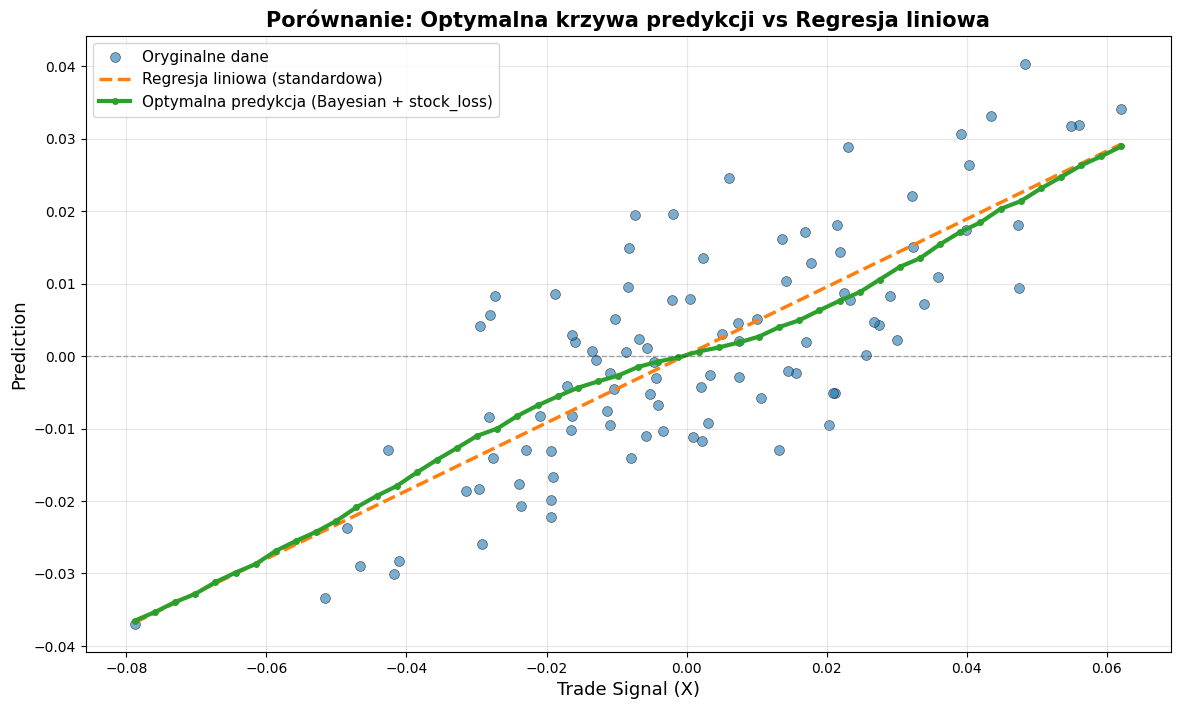


Analiza różnic między predykcjami:
Średnia predykcja - Regresja liniowa: 0.0006
Średnia predykcja - Bayesian optimal: -0.0037
Różnica średnich: 0.0044


In [45]:
# Wykres: Optymalna krzywa predykcji vs trade signal
plt.figure(figsize=(14, 8))

# Oryginalne dane
plt.scatter(X.ravel(), y, c='C0', alpha=0.6, s=50, label='Oryginalne dane', edgecolors='black', linewidth=0.5)

# Predykcja regresji liniowej
plt.plot(X.ravel()[sort_idx], y_pred_sorted, c='C1', linewidth=2.5, 
         label='Regresja liniowa (standardowa)', linestyle='--')

# Optymalna predykcja z modelu bayesowskiego
plt.plot(trade_signals, opt_predictions, c='C2', linewidth=3, 
         label='Optymalna predykcja (Bayesian + stock_loss)', marker='o', markersize=4)

plt.xlabel('Trade Signal (X)', fontsize=13)
plt.ylabel('Prediction', fontsize=13)
plt.title('Porównanie: Optymalna krzywa predykcji vs Regresja liniowa', 
          fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
plt.show()

# Wyświetlenie różnic
print("\nAnaliza różnic między predykcjami:")
print(f"Średnia predykcja - Regresja liniowa: {y_pred.mean():.4f}")
print(f"Średnia predykcja - Bayesian optimal: {opt_predictions.mean():.4f}")
print(f"Różnica średnich: {abs(y_pred.mean() - opt_predictions.mean()):.4f}")